# Experiments for $\operatorname{BE}(\alpha)$

## Imports and setup

In [1]:
from abc import ABC, abstractmethod
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

## Agents

In [2]:
from abc import ABC, abstractmethod

class Agent(ABC):
    def __init__(self, K, name):
        self.K = K
        self.name = name

    @abstractmethod
    def pull(self):
        pass

    @abstractmethod
    def observe(self, reward):
        pass

    @abstractmethod
    def reset(self):
        pass

### Random agent

In [3]:
class RandomAgent(Agent):
    def __init__(self, K, seed):
        super().__init__(K, 'Random')
        self.seed = seed

    def pull(self):
        return self.rng.integers(1, self.K)

    def observe(self, reward):
        pass
    
    def reset(self):
        self.rng = np.random.default_rng(seed=self.seed)

### Windowed agent

In [4]:
class WindowedAgent(Agent):
    def __init__(self, K, name):
        super().__init__(K, name)

    @abstractmethod
    def _get_window_length(self):
        pass

    @abstractmethod
    def _reset_window(self):
        pass

    def _update_window(self):
        self.d += 1
        if self.d == self._get_window_length() + 1:
            self.w += 1
            self.d = 1
            self._reset_window()
    
    def reset(self):
        self.w = 1
        self.d = 1

#### $\operatorname{BE}(\alpha)$

In [5]:
class BEAlphaAgent(WindowedAgent):
    def __init__(self, K, alpha, sigma):
        super().__init__(K, '$\\operatorname{BE}(\\alpha)$')
        self.alpha = alpha
        self.sigma = sigma

    def pull(self):
        self.last_pulled = min(self.B) + 1
        return self.last_pulled

    def observe(self, reward):
        self.S[self.last_pulled - 1] += reward
        self.B.remove(self.last_pulled - 1)

        if not self.B:
            self._eliminate_arms()

        self._update_window()

    def _get_window_length(self):
        return int(np.ceil(self.w ** self.alpha))

    def _eliminate_arms(self):
        S_star = max([self.S[i] for i in self.A])
        delta_w = self._get_window_length()
        B_w = 2 * (1 + 2 * self.sigma * np.sqrt(delta_w * np.log(2 * self.K * delta_w)))
        self.A = {i for i in self.A if self.S[i] + B_w >= S_star}
        self.B = self.A.copy()

    def _reset_window(self):
        self.S = [0.0] * self.K
        self.A = set(range(self.K))
        self.B = self.A.copy()
    
    def reset(self):
        super().reset()
        self._reset_window()

#### Rexp3

In [6]:
# TODO: this is NOT for sigma-subgaussian random variables
class Rexp3Agent(WindowedAgent):
    def __init__(self, K, delta, gamma, seed):
        super().__init__(K, 'Rexp3')
        self.delta = delta
        self.gamma = gamma
        self.seed = seed

    def pull(self):
        self.last_pulled = self.rng.choice(np.arange(1, self.K + 1), p=self.p)
        return self.last_pulled

    def observe(self, reward):
        self.weights[self.last_pulled - 1] *= np.exp(self.gamma / self.K * reward / self.p[self.last_pulled - 1])
        self._update_p()
        self._update_window()

    def _get_window_length(self):
        return self.delta

    def _reset_window(self):
        self.weights = np.ones(self.K)
        self._update_p()

    def _update_p(self):
        self.p = (1 - self.gamma) * self.weights / np.sum(self.weights) + self.gamma / self.K
    
    @staticmethod
    def tune_delta(T, K, V_T):
        return int(np.ceil( (K * np.log(K)) ** (1/3) * (T/V_T) ** (2/3) ))

    @staticmethod
    def tune_gamma(T, K, V_T):
        return min([1, np.sqrt(K * np.log(K) / (np.e - 1) / Rexp3Agent.tune_delta(T, K, V_T))])

    def reset(self):
        super().reset()
        self.rng = np.random.default_rng(seed=self.seed)
        self._reset_window()

### R-less-UCB

In [7]:
class RLessUCBAgent(Agent):
    def __init__(self, K, epsilon, alpha, sigma, initial_capacity=2**20):
        super().__init__(K, 'R-less-UCB')
        self.epsilon = epsilon
        self.alpha = alpha
        self.sigma = sigma
        self.rewards = np.full((self.K, initial_capacity), np.nan)

    def pull(self):
        self.last_pulled = np.argmax(self.ucbs) + 1
        return self.last_pulled

    def observe(self, reward):
        if self.rewards_counts[self.last_pulled - 1] >= self.rewards.shape[1]:
            self._expand_rewards()

        self.rewards[self.last_pulled - 1, self.rewards_counts[self.last_pulled - 1]] = reward
        self.rewards_counts[self.last_pulled - 1] += 1
        
        old_h = self.h[self.last_pulled-1]
        self.h[self.last_pulled-1] = int(np.floor(self.epsilon * self.rewards_counts[self.last_pulled - 1]))
        h = self.h[self.last_pulled-1]
        n = self.rewards_counts[self.last_pulled-1]
        old_reward = self.rewards[self.last_pulled-1, n-h-1]
        old_oldish_reward = self.rewards[self.last_pulled-1, n-2*h]
        old_old_reward = self.rewards[self.last_pulled-1, n-2*h-1]
        if self.h[self.last_pulled-1] == old_h:
            self.a[self.last_pulled-1] += reward - old_reward
            self.b[self.last_pulled-1] += old_reward - old_old_reward
            self.c[self.last_pulled-1] += n*reward - (n-h)*old_reward
            self.d[self.last_pulled-1] += n*old_reward - (n-h)*old_old_reward
        else:
            self.a[self.last_pulled-1] += reward
            self.b[self.last_pulled-1] += old_oldish_reward
            self.c[self.last_pulled-1] += n*reward
            self.d[self.last_pulled-1] += (n-h)*old_oldish_reward + self.b[self.last_pulled-1]
        self.t += 1

        self._update_preds_ucbs()

    def _expand_rewards(self):
        new_capacity = self.rewards.shape[1] * 2
        new_rewards = np.full((self.K, new_capacity), np.nan)
        new_rewards[:, :self.rewards.shape[1]] = self.rewards
        self.rewards = new_rewards

    def _update_preds_ucbs(self):
        self.preds[self.h == 0] = np.inf
        self.ucbs[self.h == 0] = np.inf

        self.preds[self.h > 0] = 1/self.h[self.h > 0] * (self.a[self.h > 0] + self.t*(self.a[self.h > 0] - self.b[self.h > 0])/self.h[self.h > 0] - (self.c[self.h > 0] - self.d[self.h > 0])/self.h[self.h > 0])

        delta_t = self.t ** (-self.alpha)
        self.ucbs[self.h > 0] = self.preds[self.h > 0] + self.sigma * (self.t - self.rewards_counts[self.h > 0] + self.h[self.h > 0] - 1) * np.sqrt(10 * np.log(1/delta_t) / (self.h[self.h > 0] ** 3))
    
    def reset(self):
        self.rewards_counts = np.zeros(self.K, dtype=int)
        self.h = np.zeros(self.K, dtype=int)
        self.preds = np.full(self.K, np.inf)
        self.ucbs = np.full(self.K, np.inf)
        self.a = np.zeros(self.K)
        self.b = np.zeros(self.K)
        self.c = np.zeros(self.K)
        self.d = np.zeros(self.K)
        self.t = 1

### UCB1

In [8]:
class UCB1Agent(Agent):
    def __init__(self, K, sigma):
        super().__init__(K, 'UCB1')
        self.sigma = sigma

    def pull(self):
        self.last_pulled = np.argmax(self.ucbs) + 1
        return self.last_pulled

    def observe(self, reward):
        self.counts[self.last_pulled - 1] += 1
        self.cumulative_rewards[self.last_pulled - 1] += reward

        self.t += 1
        self._update_ucbs()
    
    def _update_ucbs(self):
        self.ucbs[self.counts == 0] = np.inf
        self.ucbs[self.counts > 0] = self.cumulative_rewards[self.counts > 0] / self.counts[self.counts > 0] + self.sigma * np.sqrt(2 * np.log(1 + self.t * np.log(self.t) ** 2) / self.counts[self.counts > 0])
    
    def reset(self):
        self.counts = np.zeros(self.K, dtype=int)
        self.cumulative_rewards = np.zeros(self.K)
        self.ucbs = np.full(self.K, np.inf)
        self.t = 1

## Instances

In [9]:
class Instance(ABC):
    def __init__(self, K):
        self.K = K

    @abstractmethod
    def next_payoffs(self):
        pass

    @abstractmethod
    def reset(self):
        pass

In [10]:
def plot_instance(instance, T):
    instance.reset()

    payoffs = np.zeros((T, instance.K))

    for t in range(T):
        payoffs[t] = instance.next_payoffs()

    plt.figure(figsize=(12, 6))
    for i in range(instance.K):
        plt.plot(np.arange(1, T+1), payoffs[:, i], label=f'Arm {i+1}', alpha=0.7)

    plt.xlabel("Round (t)")
    plt.ylabel("Payoffs")
    plt.title("Instance Payoff Curves Over Time")
    plt.grid(True, linestyle='--', alpha=0.5)
    if instance.K <= 15:
        plt.legend()
    plt.tight_layout()
    plt.show()

### Random instance

In [11]:
class RandomInstance(Instance):
    def __init__(self, K, seed):
        super().__init__(K)
        self.seed = seed

    def next_payoffs(self):
        return tuple(self.rng.uniform(0, 1) for _ in range(self.K))

    def reset(self):
        self.rng = np.random.default_rng(seed=self.seed)

### Exponential instance

In [12]:
class ExponentialInstance(Instance):
    def __init__(self, K, seed):
        super().__init__(K)
        
        rng = np.random.default_rng(seed=seed)
        self.c = 1 - rng.random(K)
        self.a = 1 - rng.random(K)

    def next_payoffs(self):
        payoffs = self.c * (1 - np.exp(-self.a * self.t))
        self.t += 1
        return payoffs

    def reset(self):
        self.t = 1

### Polynomial instance

In [13]:
class PolynomialInstance(Instance):
    def __init__(self, K, seed):
        super().__init__(K)
        
        rng = np.random.default_rng(seed=seed)
        self.c = 1 - rng.random(K)
        self.a = 1 - rng.random(K)
        self.rho = 1 - rng.random(K)
        self.b = rng.exponential(K)

    def next_payoffs(self):
        payoffs = self.c * (1 - self.b * (self.t + self.b ** ( 1. / self.rho )) ** (-self.rho) )
        self.t += 1
        return payoffs

    def reset(self):
        self.t = 1

### Windowed instance

In [14]:
class WindowedInstance(Instance):
    @abstractmethod
    def _get_window_length(self):
        pass

    def _update_window(self):
        self.d += 1
        if self.d == self._get_window_length() + 1:
            self.w += 1
            self.d = 1
            self._reset_window()
    
    def reset(self):
        self.w = 1
        self.d = 1

#### Lower bound instance

In [15]:
class LowerBoundInstance(WindowedInstance):
    def __init__(self, K, T, V_T, seed):
        super().__init__(K)
        self.K = K
        self.delta_c = 1/3
        self.m_0 = (1-2*self.delta_c) * min([1, V_T]) / 2 / T
        self.N_c = np.ceil(T**(1/5) * K**(-1/5) * min([1, V_T])**(2/5))
        self.big_delta_c = int(np.ceil(T/self.N_c))
        self.seed = seed
    
    def next_payoffs(self):
        m_high = (2 * self.N_c - (2*self.w - 2)) * self.m_0 / 2 / self.N_c
        m_mid  = (2 * self.N_c - (2*self.w - 1)) * self.m_0 / 2 / self.N_c
        m_low  = (2 * self.N_c - 2*self.w)       * self.m_0 / 2 / self.N_c
        self.payoffs[np.arange(self.K) != self.modified_arm-1] += m_mid
        self.payoffs[self.modified_arm-1] += m_high if self.d <= float(self.big_delta_c)/2 else m_low
        self._update_window()
        return self.payoffs

    def _get_window_length(self):
        return self.big_delta_c
    
    def _reset_window(self):
        self.modified_arm = self.rng.integers(1, self.K)

    def reset(self):
        super().reset()
        self.payoffs = np.full(self.K, self.delta_c)
        self.rng = np.random.default_rng(seed=self.seed)
        self._reset_window()

## Runs

In [16]:
def run(T, agent, instance, sigma, r, seed):
    agent.reset()
    instance.reset()

    rng = np.random.default_rng(seed=seed)
    cumulative_regret = np.zeros(T + 1)

    for t in trange(1, T + 1, desc=f'Evaluating agent {agent.name}, run #{r+1}'):
        payoffs = instance.next_payoffs()

        arm = agent.pull()
        arm_index = arm - 1

        noise = rng.normal(0, sigma)
        reward = payoffs[arm_index] + noise

        agent.observe(reward)

        best_payoff = max(payoffs)
        instantaneous_regret = best_payoff - payoffs[arm_index]
        cumulative_regret[t] = cumulative_regret[t - 1] + instantaneous_regret

    return cumulative_regret[1:]

In [17]:
def compare_agents(T, agents, instance, sigma, n_runs, seed):
    cumulative_regrets_avg_std_min_max = dict()

    for agent in agents:
        cumulative_regrets = np.zeros((n_runs, T))

        for r in range(n_runs):
            cumulative_regrets[r, :] = run(T, agent, instance, sigma, r, seed+r)

        cumulative_regrets_avg_std_min_max[agent.name] = (np.mean(cumulative_regrets, axis=0), np.std(cumulative_regrets, axis=0),
                                                          np.min(cumulative_regrets, axis=0), np.max(cumulative_regrets, axis=0))

    return (cumulative_regrets_avg_std_min_max, n_runs)

def plot_comparison(results, plot_horizon=None):
    cumulative_regrets_avg_std_min_max = results[0]
    n_runs = results[1]
    agents_names = cumulative_regrets_avg_std_min_max.keys()
    if plot_horizon is None:
        plot_horizon = list(cumulative_regrets_avg_std_min_max.values())[0][0].size

    plt.figure(figsize=(10, 6))

    # Plot each agent's performance
    for agent_name in agents_names:
        plt.plot(np.arange(1, plot_horizon+1), cumulative_regrets_avg_std_min_max[agent_name][0][:plot_horizon], label=f'{agent_name}', linewidth=2)
        plt.fill_between(np.arange(1, plot_horizon+1),
                        #  cumulative_regrets_avg_std_min_max[agent_name][2][:plot_horizon],
                        #  cumulative_regrets_avg_std_min_max[agent_name][3][:plot_horizon],
                         cumulative_regrets_avg_std_min_max[agent_name][0][:plot_horizon] - 1.96 * cumulative_regrets_avg_std_min_max[agent_name][1][:plot_horizon] / np.sqrt(n_runs),
                         cumulative_regrets_avg_std_min_max[agent_name][0][:plot_horizon] + 1.96 * cumulative_regrets_avg_std_min_max[agent_name][1][:plot_horizon] / np.sqrt(n_runs),
                         alpha=0.2)

    plt.xlabel("Round (t)")
    plt.ylabel("Cumulative Regret")
    plt.title("Comparison of Multiple Agents")
    plt.legend()
    plt.grid(True)
    plt.show()

### Sanity check

In [18]:
K = 5
T = 1000
SIGMA = 0.1
N_RUNS = 5
SEED = 42

random_agent = RandomAgent(K=K, seed=SEED)
bealpha_agent = BEAlphaAgent(K=K, alpha=0.5, sigma=SIGMA)
rexpr3_agent = Rexp3Agent(K=K, delta=100, gamma=0.1, seed=SEED)
rlessucb_agent = RLessUCBAgent(K=K, epsilon=0.1, alpha=3, sigma=SIGMA)
ucb1_agent = UCB1Agent(K=K, sigma=SIGMA)
agents = [random_agent, bealpha_agent, rexpr3_agent, rlessucb_agent, ucb1_agent]

instance = RandomInstance(K=K, seed=SEED)

results_rand_inst = compare_agents(T=T, agents=agents, instance=instance, sigma=SIGMA, n_runs=N_RUNS, seed=SEED)

Evaluating agent Random, run #5: 100%|██████████| 1000/1000 [00:00<00:00, 47015.02it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #1: 100%|██████████| 1000/1000 [00:00<00:00, 42832.24it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #2: 100%|██████████| 1000/1000 [00:00<00:00, 35094.08it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #3: 100%|██████████| 1000/1000 [00:00<00:00, 47046.13it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #4: 100%|██████████| 1000/1000 [00:00<00:00, 44408.61it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #5: 100%|██████████| 1000/1000 [00:00<00:00, 35396.76it/s]
Evaluating agent UCB1, run #5: 100%|██████████| 1000/1000 [00:00<00:00, 20846.65it/s]


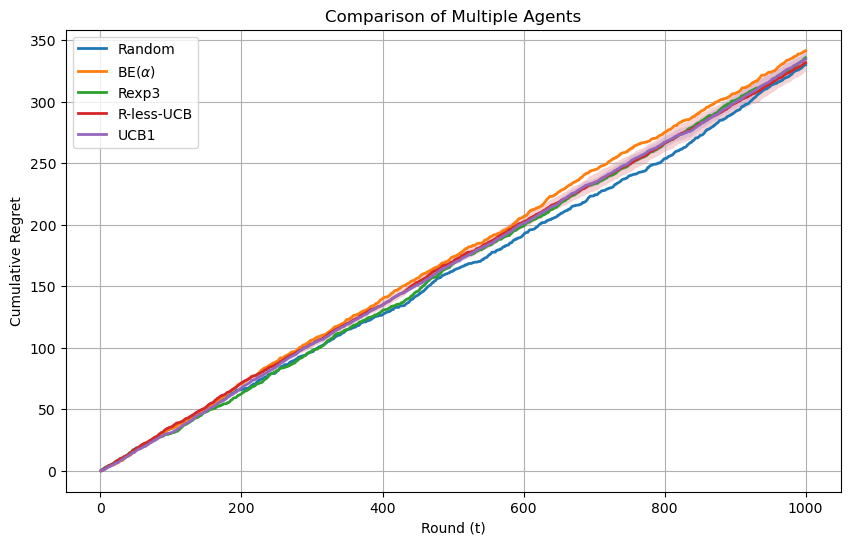

In [19]:
plot_comparison(results_rand_inst)

### Experiment on the exponential instance

/tmp/ipykernel_9850/3651235911.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/miniconda3/envs/thesis/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


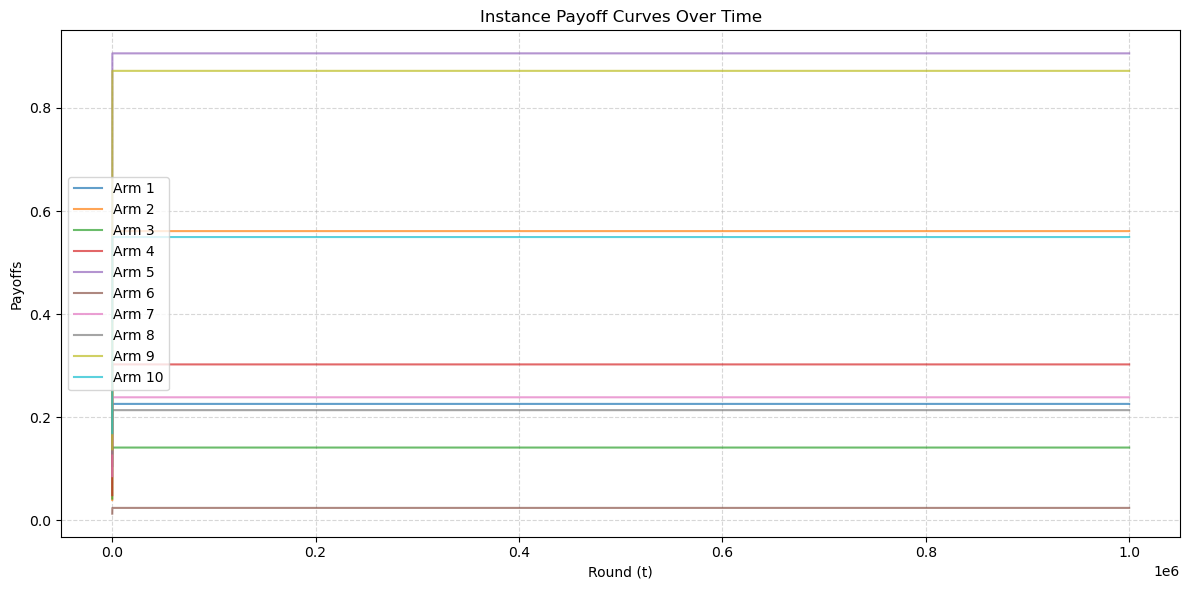

In [20]:
K = 10
T = 1000000
SIGMA = 0.1
N_RUNS = 5
SEED = 42

random_agent = RandomAgent(K=K, seed=SEED)
bealpha_agent = BEAlphaAgent(K=K, alpha=8/3, sigma=SIGMA)
rexpr3_agent = Rexp3Agent(K=K, delta=Rexp3Agent.tune_delta(T, K, K), gamma=Rexp3Agent.tune_gamma(T, K, K), seed=SEED)
rlessucb_agent = RLessUCBAgent(K=K, epsilon=0.25, alpha=2.1, sigma=SIGMA)
ucb1_agent = UCB1Agent(K=K, sigma=SIGMA)
agents = [random_agent, bealpha_agent, rexpr3_agent, rlessucb_agent, ucb1_agent]

instance = ExponentialInstance(K=K, seed=SEED)
plot_instance(instance, T)

In [21]:
results_exp_inst = compare_agents(T=T, agents=agents, instance=instance, sigma=SIGMA, n_runs=N_RUNS, seed=SEED)

Evaluating agent Random, run #5: 100%|██████████| 1000000/1000000 [00:15<00:00, 66207.37it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #1: 100%|██████████| 1000000/1000000 [00:18<00:00, 54016.62it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #2: 100%|██████████| 1000000/1000000 [00:18<00:00, 53698.22it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #3: 100%|██████████| 1000000/1000000 [00:18<00:00, 54042.55it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #4: 100%|██████████| 1000000/1000000 [00:18<00:00, 54162.63it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #5: 100%|██████████| 1000000/1000000 [00:18<00:00, 54101.08it/s]
Evaluating agent UCB1, run #5: 100%|██████████| 1000000/1000000 [00:43<00:00, 22760.50it/s]


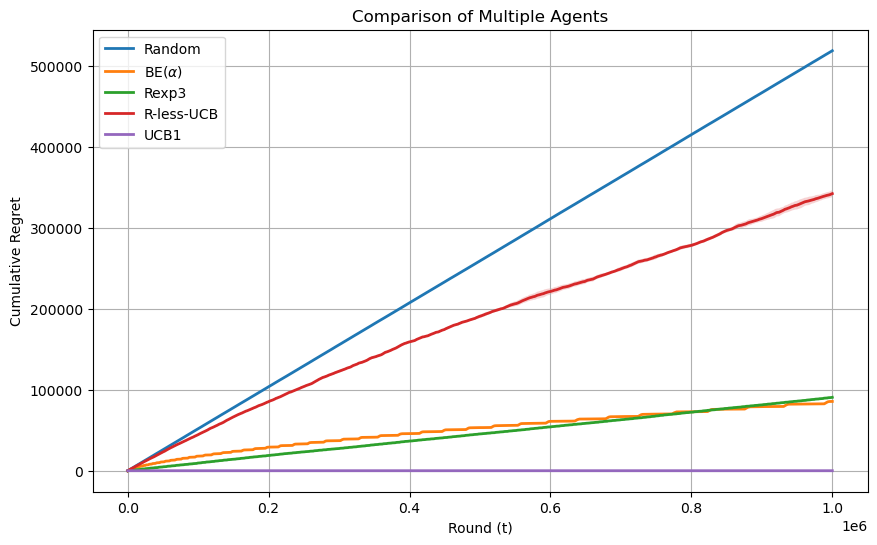

In [22]:
plot_comparison(results_exp_inst)

### Experiment on the polynomial instance

/tmp/ipykernel_9850/3651235911.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


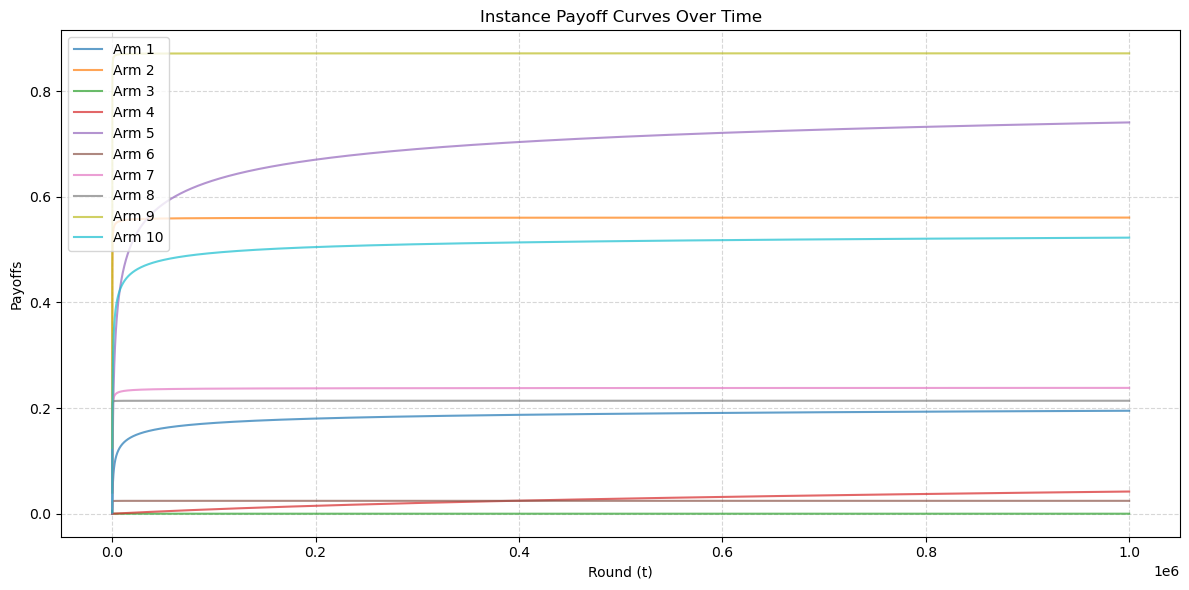

In [23]:
K = 10
T = 1000000
SIGMA = 0.1
N_RUNS = 5
SEED = 42

random_agent = RandomAgent(K=K, seed=SEED)
bealpha_agent = BEAlphaAgent(K=K, alpha=8/3, sigma=SIGMA)
rexpr3_agent = Rexp3Agent(K=K, delta=Rexp3Agent.tune_delta(T, K, K), gamma=Rexp3Agent.tune_gamma(T, K, K), seed=SEED)
rlessucb_agent = RLessUCBAgent(K=K, epsilon=0.25, alpha=2.1, sigma=SIGMA)
ucb1_agent = UCB1Agent(K=K, sigma=SIGMA)
agents = [random_agent, bealpha_agent, rexpr3_agent, rlessucb_agent, ucb1_agent]

instance = PolynomialInstance(K=K, seed=SEED)
plot_instance(instance, T)

In [24]:
results_poly_inst = compare_agents(T=T, agents=agents, instance=instance, sigma=SIGMA, n_runs=N_RUNS, seed=SEED)

Evaluating agent Random, run #5: 100%|██████████| 1000000/1000000 [00:19<00:00, 51660.57it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #1: 100%|██████████| 1000000/1000000 [00:24<00:00, 41388.93it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #2: 100%|██████████| 1000000/1000000 [00:24<00:00, 41529.13it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #3: 100%|██████████| 1000000/1000000 [00:23<00:00, 43092.18it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #4: 100%|██████████| 1000000/1000000 [00:23<00:00, 43138.46it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #5: 100%|██████████| 1000000/1000000 [00:24<00:00, 41376.13it/s]
Evaluating agent UCB1, run #5: 100%|██████████| 1000000/1000000 [00:47<00:00, 21158.73it/s]


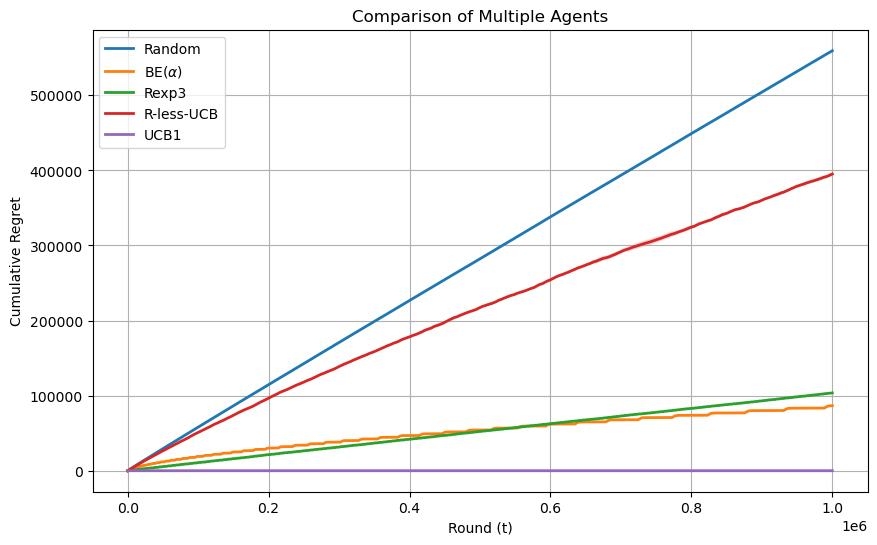

In [25]:
plot_comparison(results_poly_inst)

### Experiment on the lower bound instance

/tmp/ipykernel_9850/3651235911.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


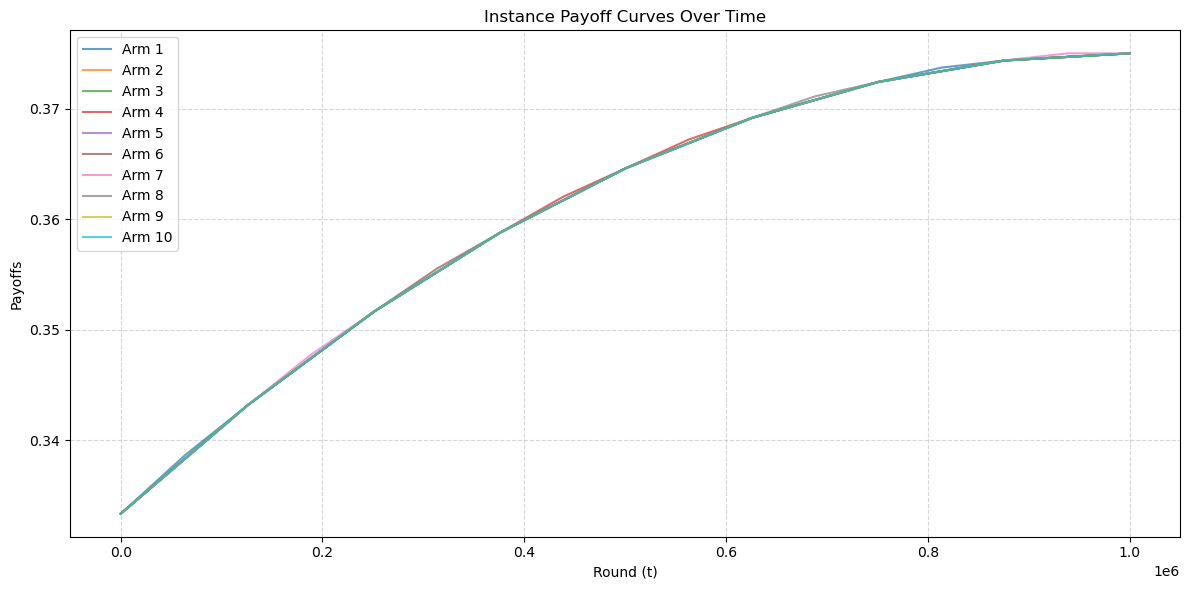

In [26]:
K = 10
T = 1000000
V_T = 0.5
SIGMA = 0.1
N_RUNS = 5
SEED = 42

random_agent = RandomAgent(K=K, seed=SEED)
bealpha_agent = BEAlphaAgent(K=K, alpha=8/3, sigma=SIGMA)
rexpr3_agent = Rexp3Agent(K=K, delta=Rexp3Agent.tune_delta(T, K, V_T), gamma=Rexp3Agent.tune_gamma(T, K, V_T), seed=SEED)
rlessucb_agent = RLessUCBAgent(K=K, epsilon=0.25, alpha=2.1, sigma=SIGMA)
ucb1_agent = UCB1Agent(K=K, sigma=SIGMA)
agents = [random_agent, bealpha_agent, rexpr3_agent, rlessucb_agent, ucb1_agent]

instance = LowerBoundInstance(K=K, T=T, V_T=V_T, seed=SEED)
plot_instance(instance, T)

In [27]:
results_low_bound_inst = compare_agents(T=T, agents=agents, instance=instance, sigma=SIGMA, n_runs=N_RUNS, seed=SEED)

Evaluating agent Random, run #5: 100%|██████████| 1000000/1000000 [00:21<00:00, 47362.35it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #1: 100%|██████████| 1000000/1000000 [00:21<00:00, 46532.73it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #2: 100%|██████████| 1000000/1000000 [00:21<00:00, 46264.97it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #3: 100%|██████████| 1000000/1000000 [00:21<00:00, 46549.39it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #4: 100%|██████████| 1000000/1000000 [00:21<00:00, 47116.62it/s]
Evaluating agent $\operatorname{BE}(\alpha)$, run #5: 100%|██████████| 1000000/1000000 [00:21<00:00, 47082.76it/s]
Evaluating agent UCB1, run #5: 100%|██████████| 1000000/1000000 [00:48<00:00, 20478.11it/s]


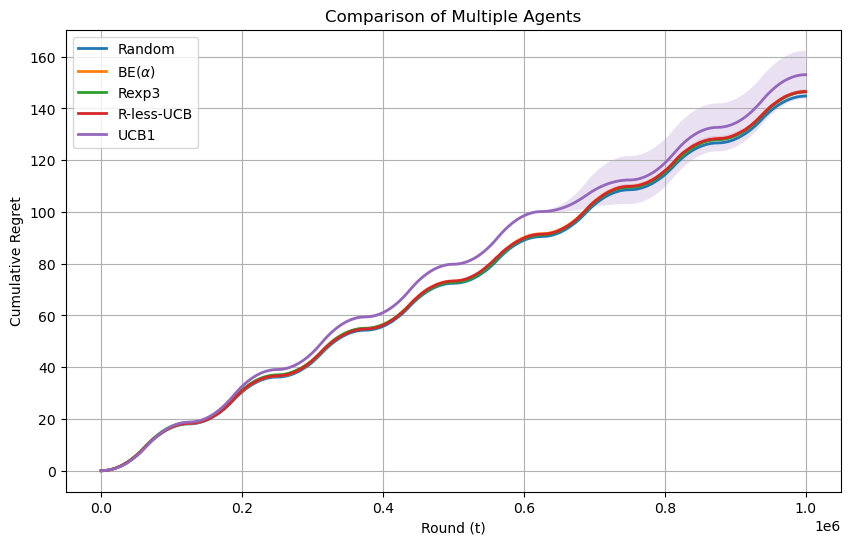

In [28]:
plot_comparison(results_low_bound_inst)